# NeuralProphet

In [11]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from neuralprophet import NeuralProphet
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt


## Load Data

In [12]:
df = pd.read_csv("electricity_daily_total.csv")

assert "ds" in df.columns and "y" in df.columns


## Preprocessing

In [13]:
df["ds"] = pd.to_datetime(df["ds"])
df = df.sort_values("ds").drop_duplicates()

df["y"] = pd.to_numeric(df["y"], errors="coerce")
df = df.fillna(method="ffill").fillna(method="bfill")


## Split 70/10/20

In [14]:
n = len(df)

train_end = int(n * 0.7)
val_end   = int(n * 0.8)

train_df = df.iloc[:train_end].copy()
val_df   = df.iloc[train_end:val_end].copy()
test_df  = df.iloc[val_end:].copy()


## Model

In [15]:
model = NeuralProphet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    n_lags=30,
    n_forecasts=1,
    learning_rate=0.001,
    epochs=200
)


## Training

In [16]:
metrics = model.fit(
    train_df,
    validation_df=val_df,
    freq='D',
    early_stopping=True
)


WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.902% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.config.set_auto_batch_epoch) - Auto-set batch_size to 32


Training: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

## Prediction

In [17]:
forecast = model.predict(df)

forecast_test = forecast.iloc[-len(test_df):].copy()

y_true = test_df["y"].values
y_pred = forecast_test["yhat1"].values


INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.932% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D


INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.932% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


## Evaluation

In [18]:
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

smape = np.mean(
    2 * np.abs(y_pred - y_true) /
    (np.abs(y_true) + np.abs(y_pred))
) * 100

naive = np.mean(np.abs(np.diff(y_true)))
mase = mae / naive

print(f"RMSE: {rmse}")
print(f"MAE : {mae}")
print(f"sMAPE: {smape}")
print(f"MASE : {mase}")


RMSE: 14413.51896483823
MAE : 10241.067145880907
sMAPE: 4.541915897843324
MASE : 1.7012825579141995


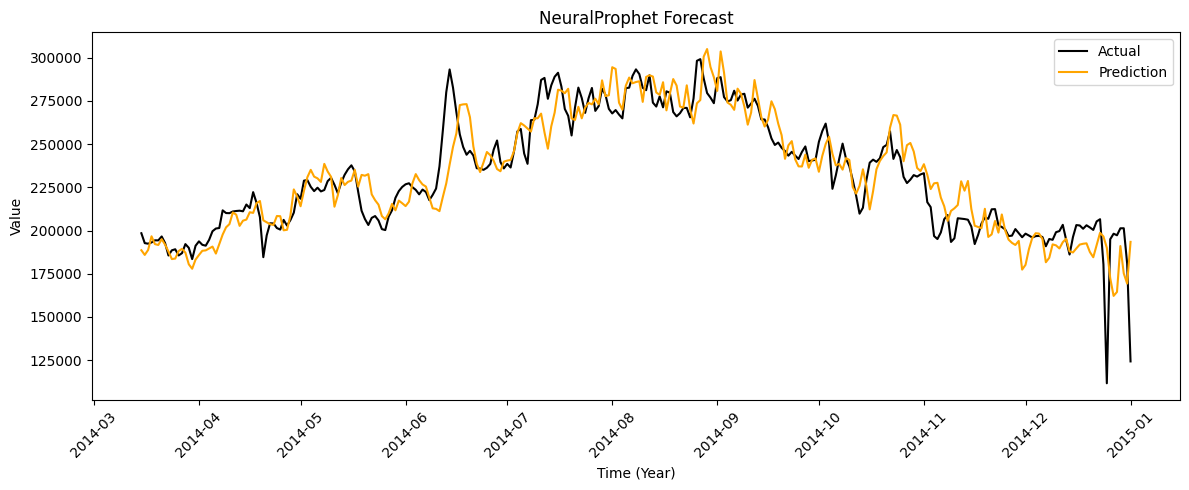

In [20]:
ds_test = test_df["ds"].iloc[:len(y_true)]

plt.figure(figsize=(12,5))

plt.plot(ds_test, y_true, label="Actual", color="black")
plt.plot(ds_test, y_pred, label="Prediction", color="orange")

plt.title("NeuralProphet Forecast")
plt.xlabel("Time (Year)")
plt.ylabel("Value")

plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()